In [1]:
import pandas as pd

In [70]:
raw_data = pd.read_csv('atl-80/DiseaseReports.tsv', sep='\t|,', engine="python")
raw_data['Age Reported'] = raw_data['Report(Single)]'].apply(lambda x: True if 'Age' in x else False)
raw_data['Gender Reported'] = raw_data['Report(Single)]'].apply(lambda x: True if 'Gender' in x else False)
raw_data['Income Reported'] = raw_data['Report(Single)]'].apply(lambda x: True if 'Income' in x else False)
raw_data['Race Reported'] = raw_data['Report(Single)]'].apply(lambda x: True if 'Race' in x else False)
raw_data['rid'] = raw_data['[regionId'].apply(lambda x: int(x[1:]))
raw_data = raw_data[['step','agentId', 'rid', 'diseaseStatus', 'Report(Component)', 'Age Reported', 'Gender Reported', 'Income Reported', 'Race Reported']]
raw_data

,step,agentId,rid,diseaseStatus,Report(Component),Age Reported,Gender Reported,Income Reported,Race Reported
0,0,0,1,Susceptible,False,False,False,False,False
1,0,1,1,Susceptible,False,False,False,False,False
2,0,2,1,Susceptible,False,False,False,False,False
3,0,3,1,Infectious,True,True,False,False,False
4,0,4,1,Susceptible,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
19486,8551,2880,16,Recovered,False,False,False,False,False
19487,8565,779,4,Recovered,False,False,False,False,False
19488,8606,3233,18,Recovered,False,False,False,False,False
19489,8618,1194,7,Recovered,False,False,False,False,False


In [71]:
import numpy as np

In [72]:
grouped_raw_data = raw_data.groupby('rid')
ground_truth_data = np.zeros((27,8640))
biased_data = np.zeros((27,8640))

In [73]:
for i in range(1,28):
    data = grouped_raw_data.get_group(i)
    i_data = data[data['diseaseStatus'] == 'Infectious']
    r_data = data[data['diseaseStatus'] == 'Recovered']
    
    i_step = list(i_data['step'])
    r_step = list(r_data['step'])
    
    for step in i_step:
        ground_truth_data[i-1,step:] += 1
    for step in r_step:
        ground_truth_data[i-1,step:] -= 1

In [74]:
import matplotlib.pyplot as plt

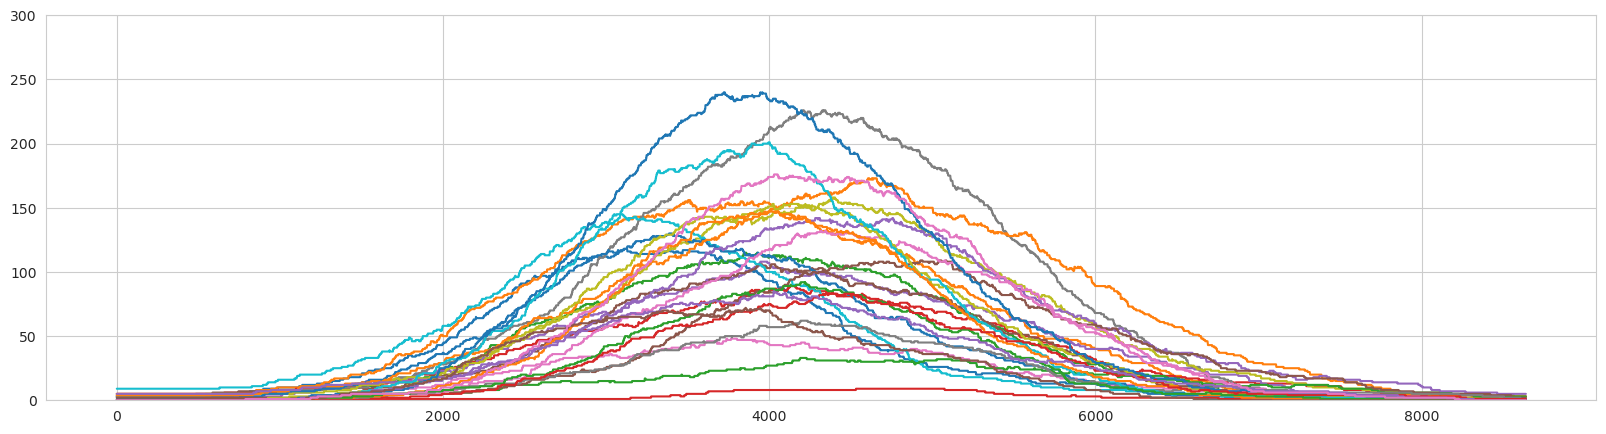

In [77]:
plt.figure(figsize=(20,5))
plt.ylim(0,300)
for i in range(27):
    plt.plot(ground_truth_data[i,:])

In [87]:
biased_data = np.zeros((27,8640))
for i in range(1,28):
    data = grouped_raw_data.get_group(i)
    i_data = data[data['diseaseStatus'] == 'Infectious']
    i_data = i_data[i_data['Age Reported']]
    r_data = data[data['diseaseStatus'] == 'Recovered']

    for _,row in i_data.iterrows():
        aid = row['agentId']
        i_step = row['step']
        a_data = r_data[r_data['agentId'] == aid]
        a_data = a_data[a_data['step'] > i_step]
        
        if len(a_data) > 0: r_data.loc[a_data.index[0], 'Age Reported'] = True

    i_step = list(i_data['step'])
    r_data = r_data[r_data['Age Reported']]
    r_step = list(r_data['step'])

    for step in i_step:
        biased_data[i-1,step:] += 1
    for step in r_step:
        biased_data[i-1,step:] -= 1

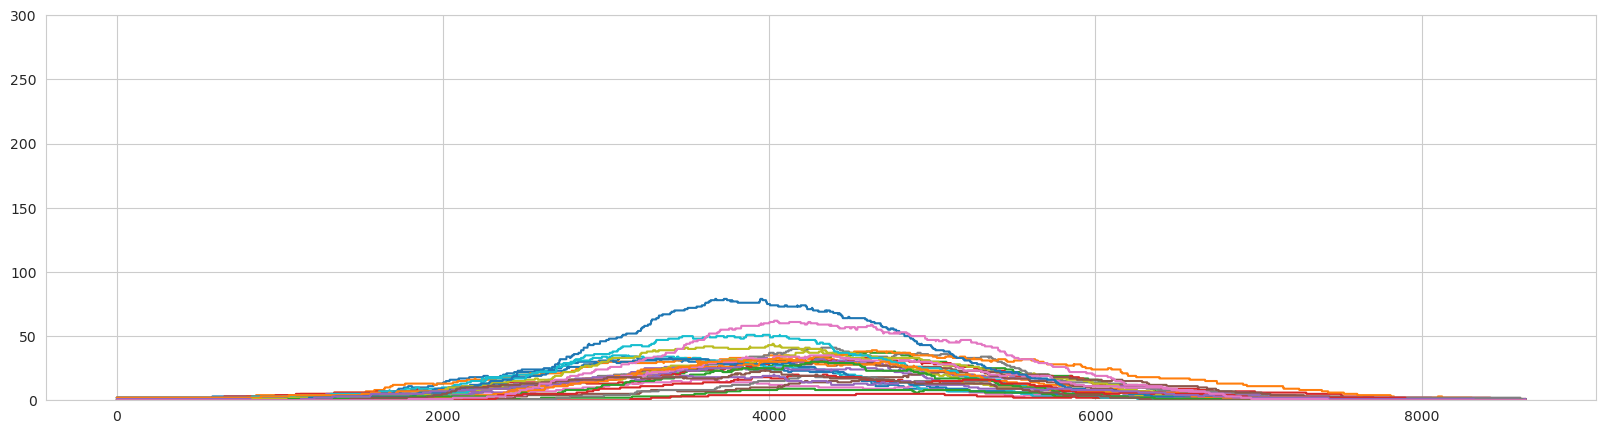

In [88]:
plt.figure(figsize=(20,5))
plt.ylim(0,300)
for i in range(27):
    plt.plot(biased_data[i,:])

In [89]:
for i in range(27):
    print(biased_data[i,:].sum()/ground_truth_data[i,:].sum())

0.2817883187701202
0.23468760570584693
0.29883731591821283
0.36944833875512123
0.2947270754655458
0.2979650782863267
0.26693994203520827
0.17584007228081866
0.2246169770485633
0.2499135580634739
0.24403079944811631
0.23770055646245006
0.19830355776912748
0.5507504894496411
0.17102973537211533
0.1899530243935108
0.26241846179856015
0.2655668363885306
0.27567905401182485
0.2569652462395723
0.3145866249025466
0.2339214652710601
0.3018525092485333
0.24772415600705805
0.2594510912410697
0.3053350764154761
0.3316030356704203


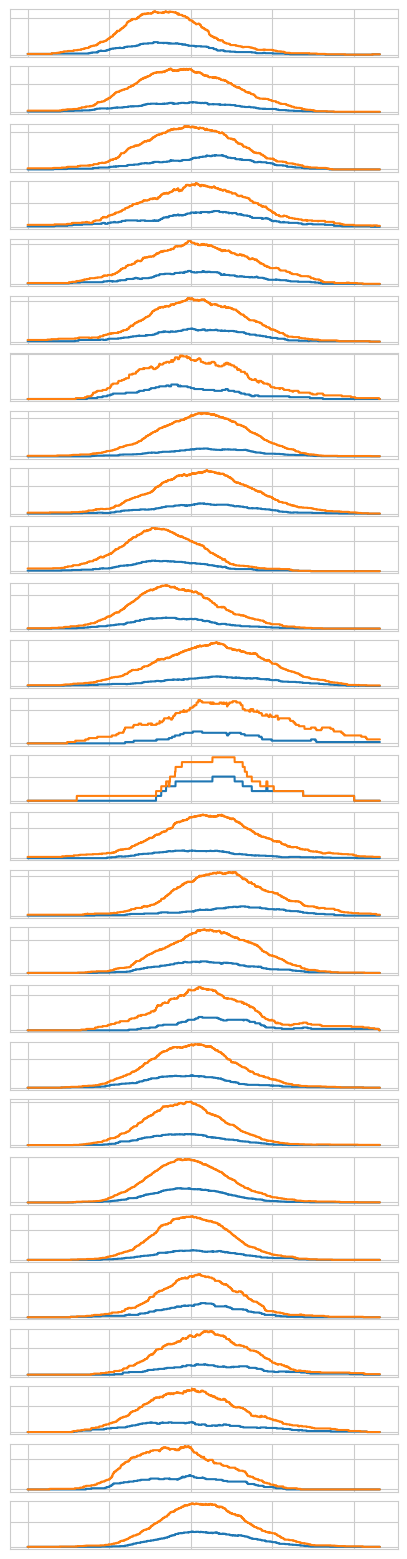

In [99]:
fig,axis = plt.subplots(27, figsize = (5,20))

for i in range(27):
    axis[i].set_xticklabels([])
    axis[i].set_yticklabels([])
    
    axis[i].plot(biased_data[i,:])
    axis[i].plot(ground_truth_data[i,:])
    

In [105]:
import os
os.mkdir('processed_data/atl-80')
os.mkdir('processed_data/atl-70')
os.mkdir('processed_data/atl-60')

In [111]:
def process_file(dirName):
    raw_data = pd.read_csv('%s/DiseaseReports.tsv'%dirName, sep='\t|,', engine="python")
    raw_data['Age Reported'] = raw_data['Report(Single)]'].apply(lambda x: True if 'Age' in x else False)
    raw_data['Gender Reported'] = raw_data['Report(Single)]'].apply(lambda x: True if 'Gender' in x else False)
    raw_data['Income Reported'] = raw_data['Report(Single)]'].apply(lambda x: True if 'Income' in x else False)
    raw_data['Race Reported'] = raw_data['Report(Single)]'].apply(lambda x: True if 'Race' in x else False)
    raw_data['rid'] = raw_data['[regionId'].apply(lambda x: int(x[1:]))
    raw_data = raw_data[['step','agentId', 'rid', 'diseaseStatus', 'Report(Component)', 'Age Reported', 'Gender Reported', 'Income Reported', 'Race Reported']]
    
    grouped_raw_data = raw_data.groupby('rid')
    ground_truth_data = np.zeros((27,8640))
    for i in range(1,28):
        data = grouped_raw_data.get_group(i)
        i_data = data[data['diseaseStatus'] == 'Infectious']
        r_data = data[data['diseaseStatus'] == 'Recovered']
    
        i_step = list(i_data['step'])
        r_step = list(r_data['step'])
    
        for step in i_step:
            ground_truth_data[i-1,step:] += 1
        for step in r_step:
            ground_truth_data[i-1,step:] -= 1
    np.save('processed_data/%s/current_infectious_Ground.npy'%dirName, ground_truth_data)
    
    def process_bias(bias):
        biased_data = np.zeros((27,8640))
        for i in range(1,28):
            data = grouped_raw_data.get_group(i)
            i_data = data[data['diseaseStatus'] == 'Infectious']
            i_data = i_data[i_data['%s Reported'%bias]]
            r_data = data[data['diseaseStatus'] == 'Recovered']
        
            for _,row in i_data.iterrows():
                aid = row['agentId']
                i_step = row['step']
                a_data = r_data[r_data['agentId'] == aid]
                a_data = a_data[a_data['step'] > i_step]
        
                if len(a_data) > 0: r_data.loc[a_data.index[0], '%s Reported'%bias] = True
        
            i_step = list(i_data['step'])
            r_data = r_data[r_data['%s Reported'%bias]]
            r_step = list(r_data['step'])
        
            for step in i_step:
                biased_data[i-1,step:] += 1
            for step in r_step:
                biased_data[i-1,step:] -= 1
                
        np.save('processed_data/%s/current_infectious_%s.npy'%(dirName,bias), ground_truth_data)

        fig,axis = plt.subplots(27, figsize = (5,20))
        fig.suptitle('%s Report'%bias)
        for i in range(27):
            axis[i].set_xticklabels([])
            axis[i].set_yticklabels([])
        
            axis[i].plot(biased_data[i,:])
            axis[i].plot(ground_truth_data[i,:])
        fig.savefig('processed_data/%s/%s.png'%(dirName,bias), dpi=100)
    
    process_bias('Age')
    process_bias('Income')
    process_bias('Gender')
    process_bias('Race')

    def process_comp():
        biased_data = np.zeros((27,8640))
        for i in range(1,28):
            data = grouped_raw_data.get_group(i)
            i_data = data[data['diseaseStatus'] == 'Infectious']
            i_data = i_data[i_data['Report(Component)']]
            r_data = data[data['diseaseStatus'] == 'Recovered']

            for _,row in i_data.iterrows():
                aid = row['agentId']
                i_step = row['step']
                a_data = r_data[r_data['agentId'] == aid]
                a_data = a_data[a_data['step'] > i_step]

                if len(a_data) > 0: r_data.loc[a_data.index[0], 'Report(Component)'] = True

            i_step = list(i_data['step'])
            r_data = r_data[r_data['Report(Component)']]
            r_step = list(r_data['step'])

            for step in i_step:
                biased_data[i-1,step:] += 1
            for step in r_step:
                biased_data[i-1,step:] -= 1

        np.save('processed_data/%s/current_infectious_Multivariate.npy'%dirName, ground_truth_data)

        fig,axis = plt.subplots(27, figsize = (5,20))
        fig.suptitle('Multivariate Report')
        for i in range(27):
            axis[i].set_xticklabels([])
            axis[i].set_yticklabels([])

            axis[i].plot(biased_data[i,:])
            axis[i].plot(ground_truth_data[i,:])
        fig.savefig('processed_data/%s/Multivariate.png'%dirName, dpi=100)
        plt.close()
    process_comp()

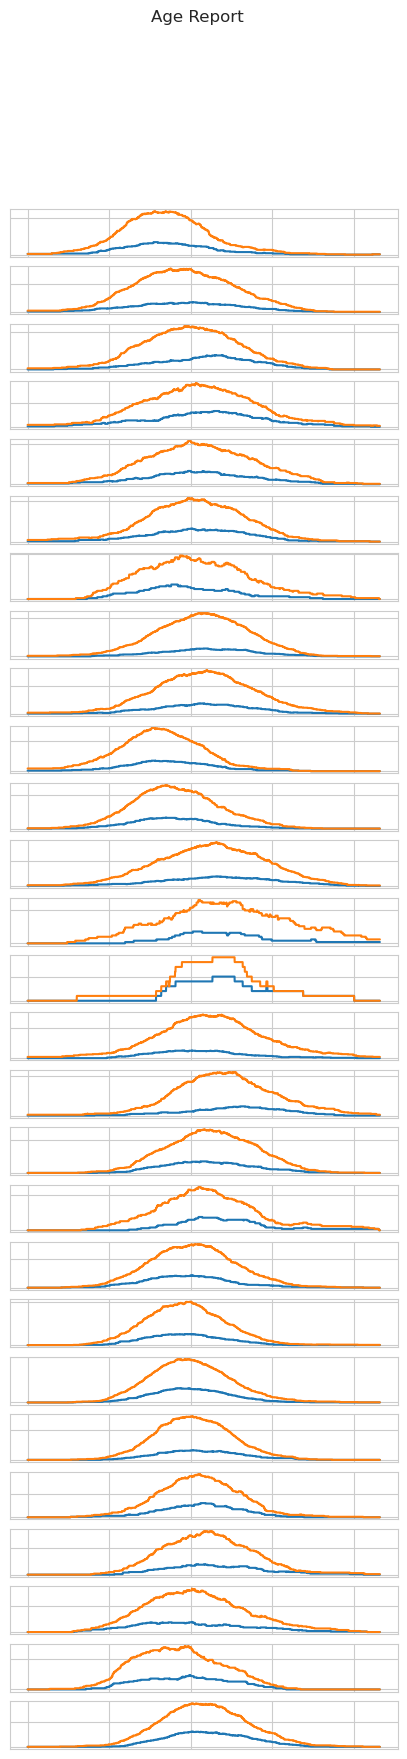

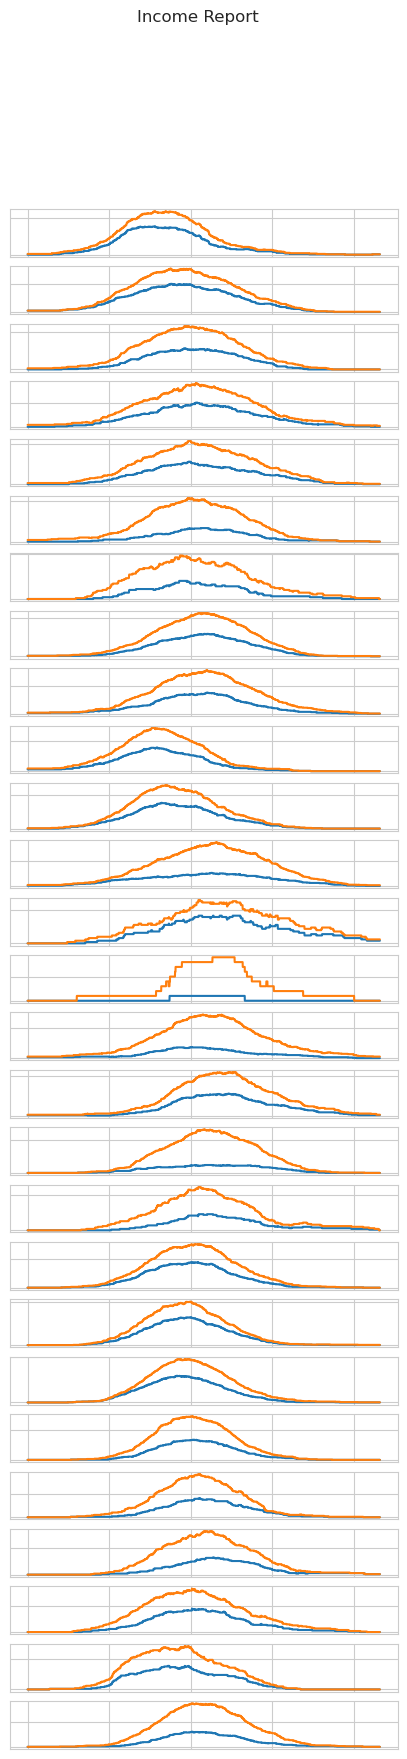

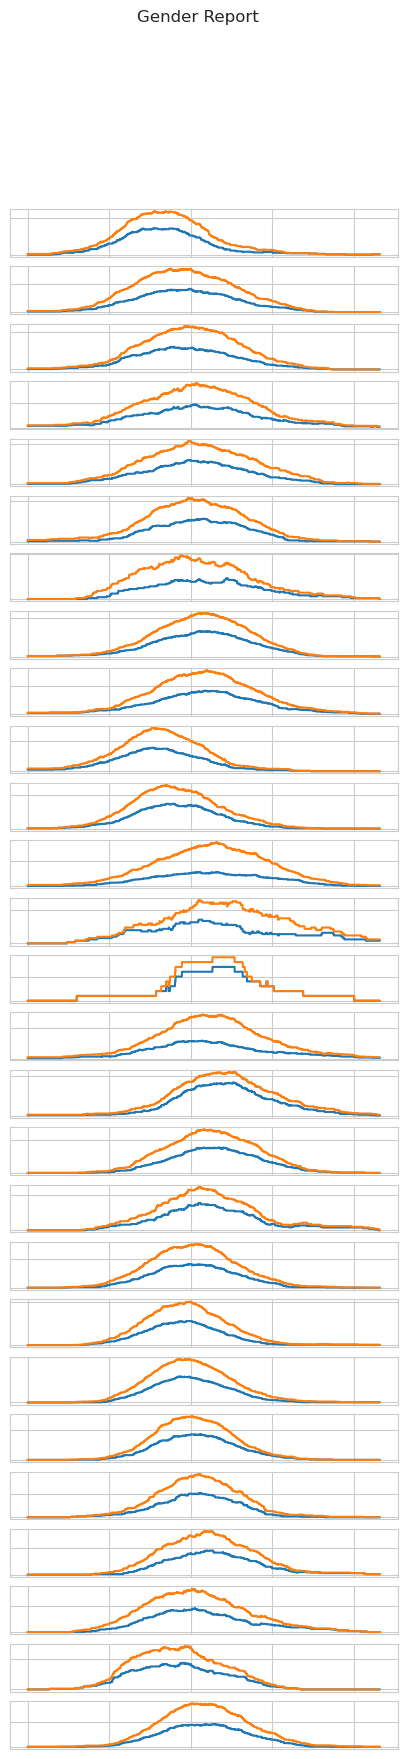

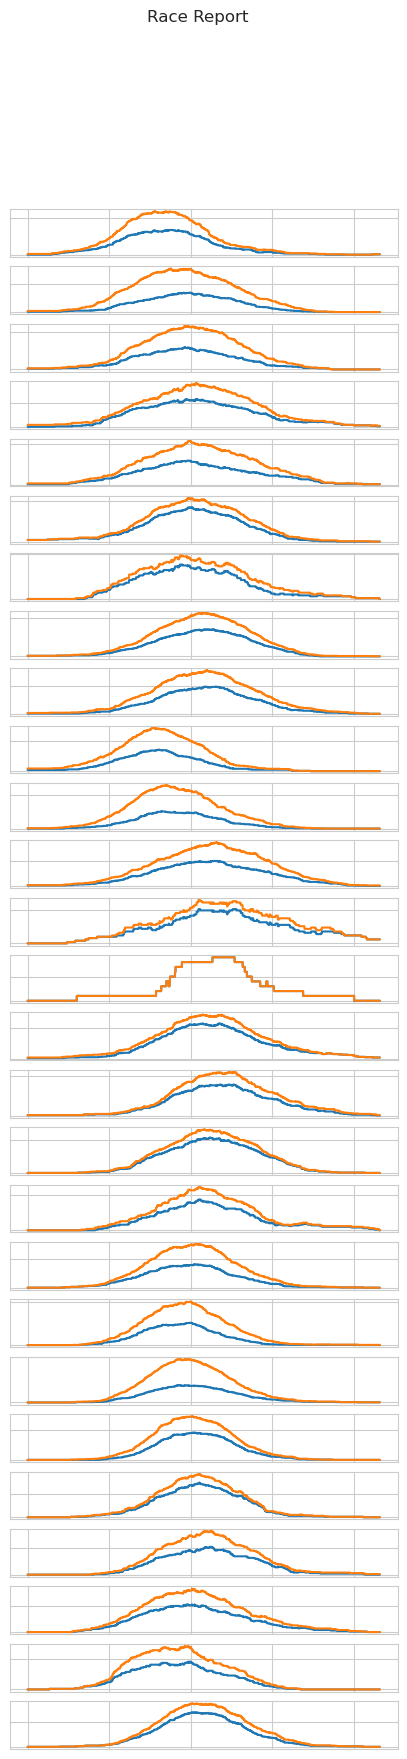

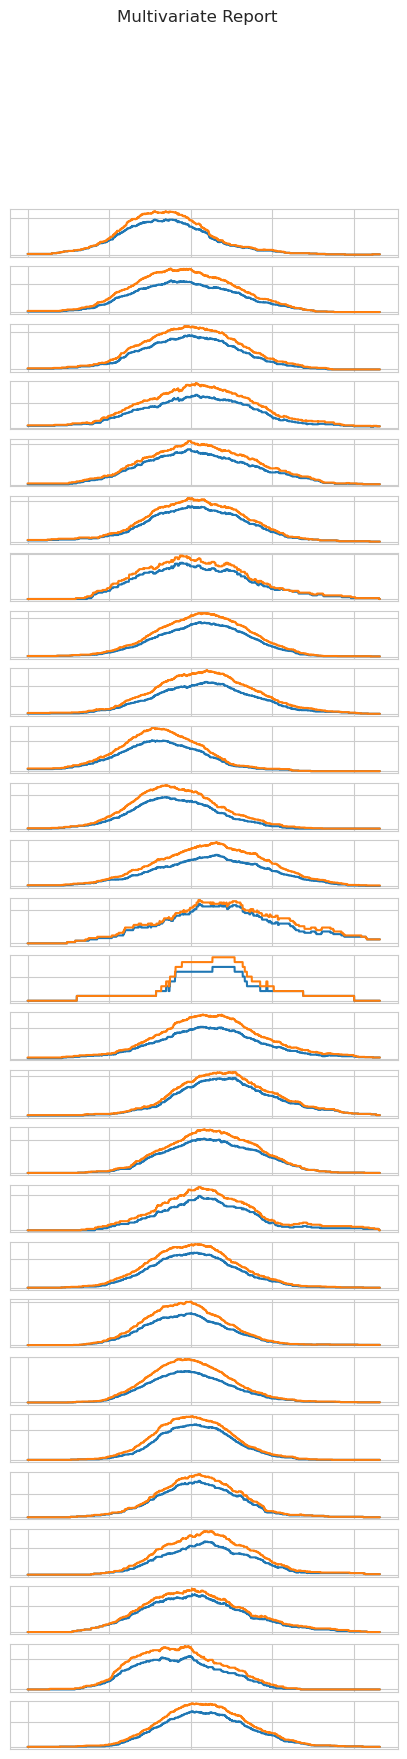

In [108]:
process_file('atl-80')

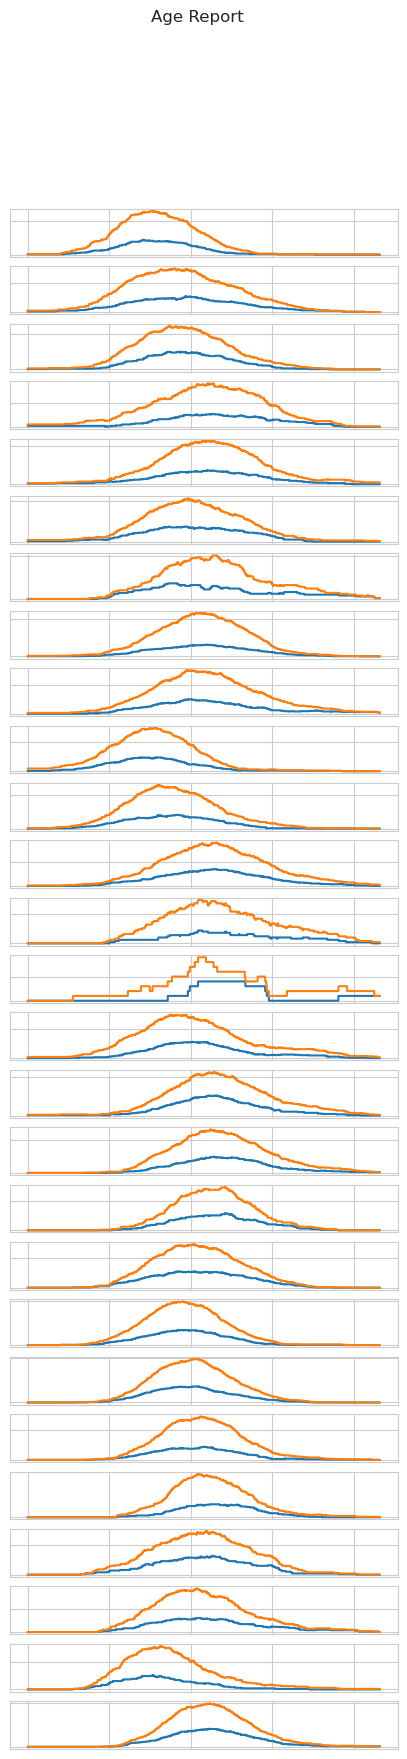

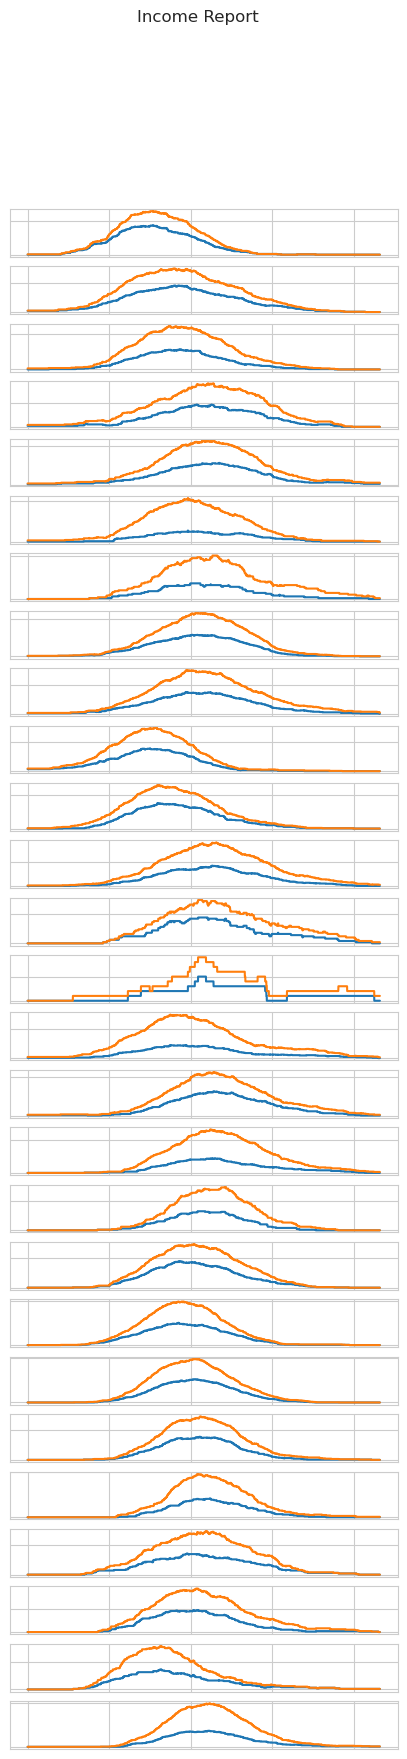

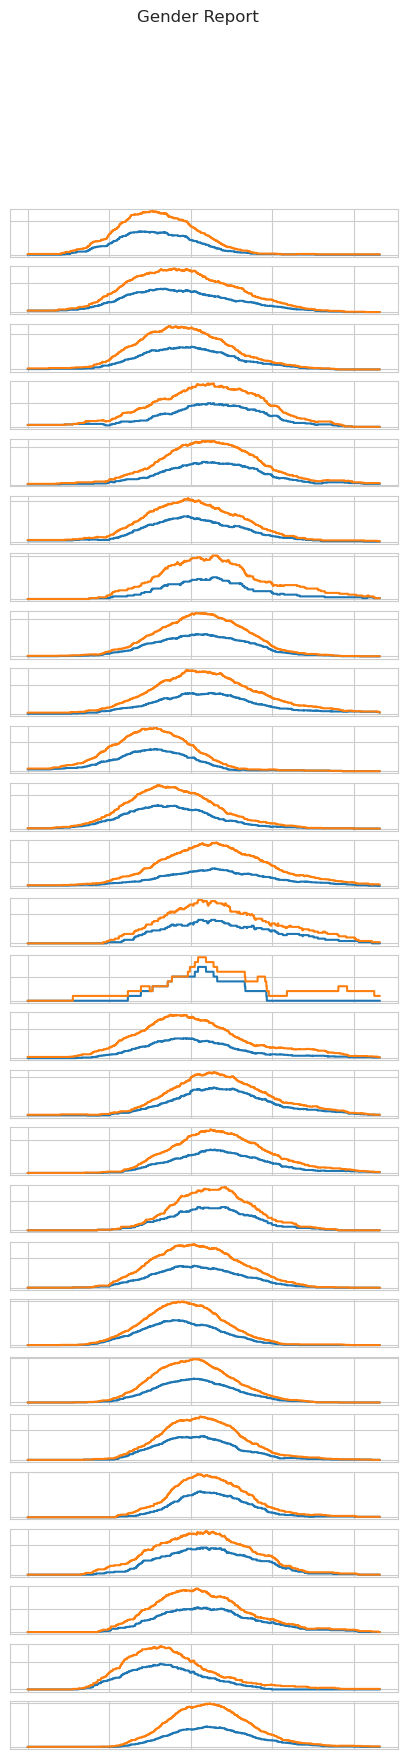

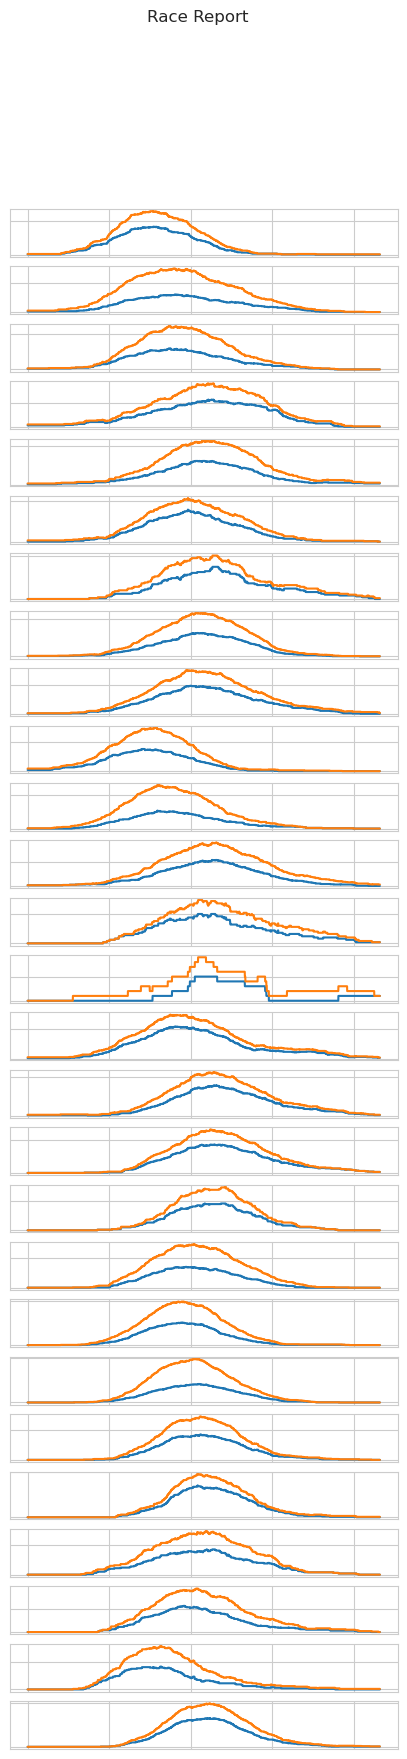

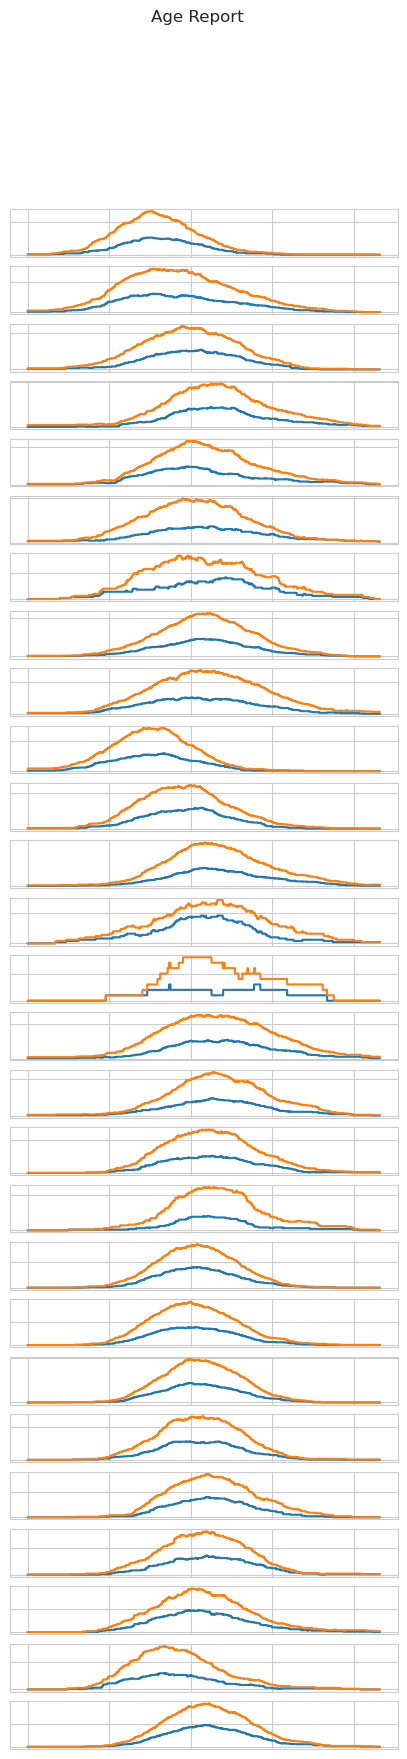

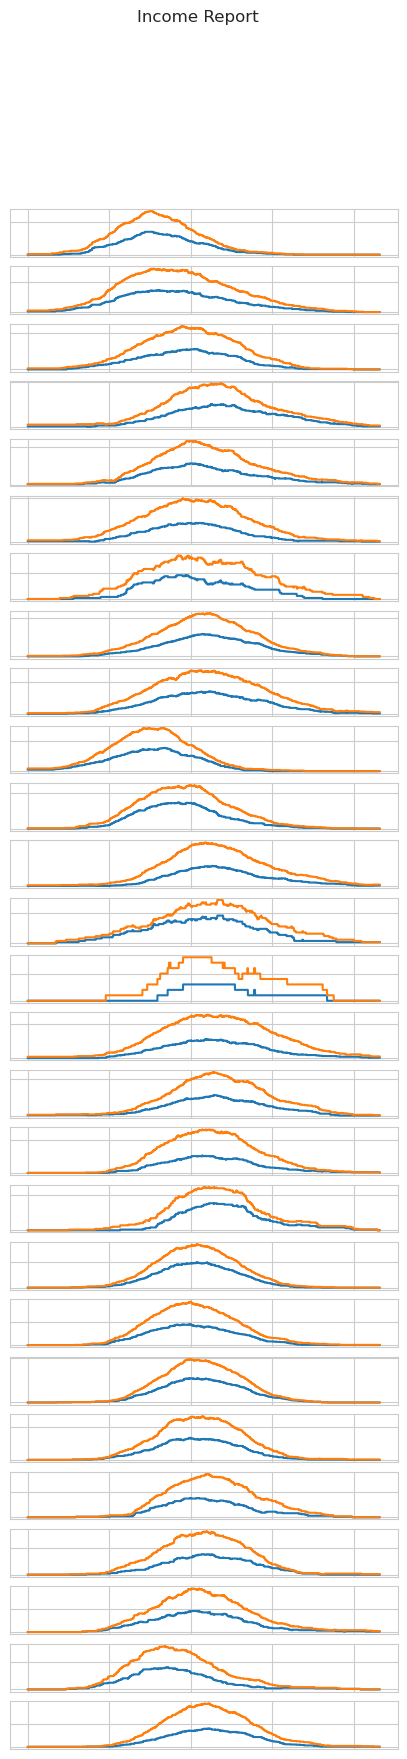

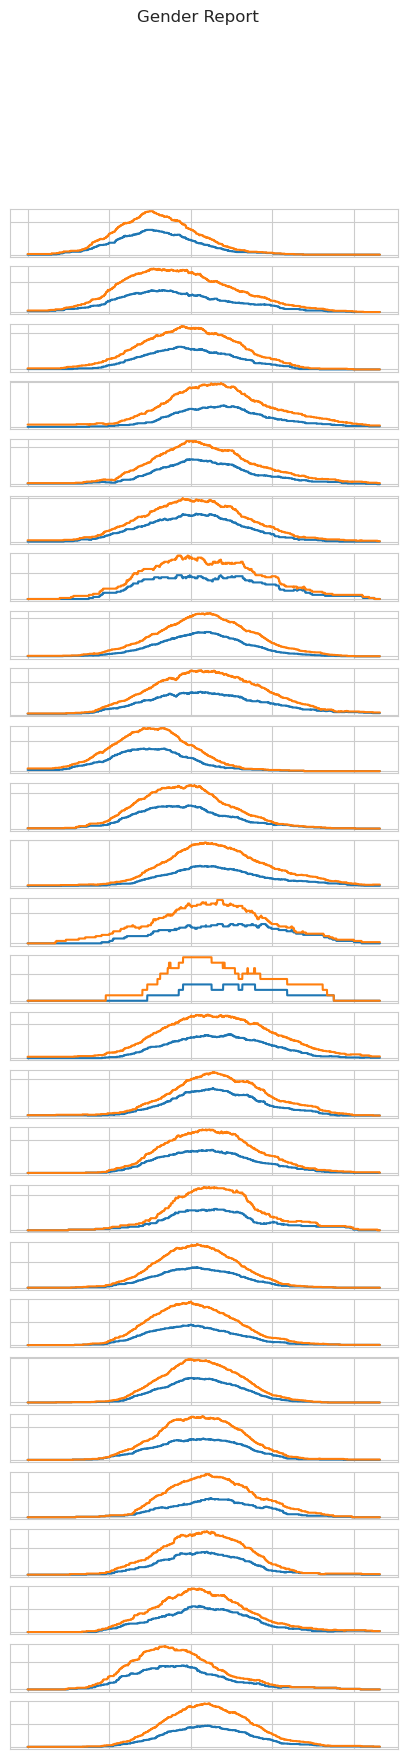

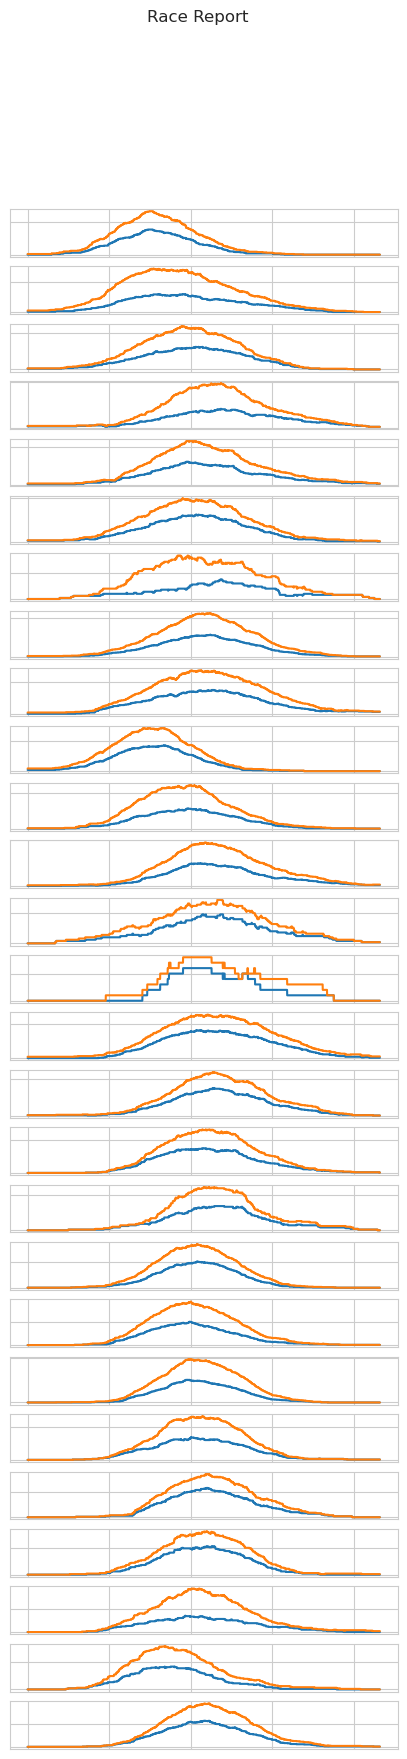

In [112]:
process_file('atl-70')
process_file('atl-60')

In [113]:
def process_total_file(dirName):
    raw_data = pd.read_csv('%s/DiseaseReports.tsv'%dirName, sep='\t|,', engine="python")
    raw_data['Age Reported'] = raw_data['Report(Single)]'].apply(lambda x: True if 'Age' in x else False)
    raw_data['Gender Reported'] = raw_data['Report(Single)]'].apply(lambda x: True if 'Gender' in x else False)
    raw_data['Income Reported'] = raw_data['Report(Single)]'].apply(lambda x: True if 'Income' in x else False)
    raw_data['Race Reported'] = raw_data['Report(Single)]'].apply(lambda x: True if 'Race' in x else False)
    raw_data['rid'] = raw_data['[regionId'].apply(lambda x: int(x[1:]))
    raw_data = raw_data[['step','agentId', 'rid', 'diseaseStatus', 'Report(Component)', 'Age Reported', 'Gender Reported', 'Income Reported', 'Race Reported']]

    grouped_raw_data = raw_data.groupby('rid')
    ground_truth_data = np.zeros((27,8640))
    for i in range(1,28):
        data = grouped_raw_data.get_group(i)
        i_data = data[data['diseaseStatus'] == 'Infectious']
        i_step = list(i_data['step'])
        for step in i_step:
            ground_truth_data[i-1,step:] += 1
    np.save('processed_data/%s/total_infected_Ground.npy'%dirName, ground_truth_data)

    def process_bias(bias):
        biased_data = np.zeros((27,8640))
        for i in range(1,28):
            data = grouped_raw_data.get_group(i)
            i_data = data[data['diseaseStatus'] == 'Infectious']
            i_data = i_data[i_data['%s Reported'%bias]]
            i_step = list(i_data['step'])
            for step in i_step:
                biased_data[i-1,step:] += 1

        np.save('processed_data/%s/total_infected_%s.npy'%(dirName,bias), ground_truth_data)
        
    process_bias('Age')
    process_bias('Income')
    process_bias('Gender')
    process_bias('Race')

    def process_comp():
        biased_data = np.zeros((27,8640))
        for i in range(1,28):
            data = grouped_raw_data.get_group(i)
            i_data = data[data['diseaseStatus'] == 'Infectious']
            i_data = i_data[i_data['Report(Component)']]
            i_step = list(i_data['step'])

            for step in i_step:
                biased_data[i-1,step:] += 1

        np.save('processed_data/%s/total_infected_Multivariate.npy'%dirName, ground_truth_data)
    process_comp()

In [114]:
process_total_file('atl-70')
process_total_file('atl-80')
process_total_file('atl-60')